In [98]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [99]:
#IMPORT CSV
df = pd.read_csv('crop.csv')

In [100]:
#CHECK CSV
print(df.info())
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass distribution:\n", df["Crop"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Null values:
 Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

Duplicates: 0

Class distribution:
 Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana   

In [101]:
#SPLIT 20/80
inputs = df.drop(columns="Crop").values.astype(np.float32)
labels = df["Crop"].values

nb_samples = len(labels)
indices = np.random.permutation(nb_samples)
split = int(0.8 * nb_samples)
train_indxs = indices[:split]
test_indxs = indices[split:]
train_data = {'x': inputs[train_indxs], 'y': labels[train_indxs]}
test_data = {'x': inputs[test_indxs], 'y': labels[test_indxs]}

print(f"Train: {len(train_data['y'])} | Test: {len(test_data['y'])}")

Train: 1760 | Test: 440


In [102]:
#CREATE DECISION TREE
dt = DecisionTreeClassifier(criterion="gini", random_state=42)
dt.fit(train_data['x'], train_data['y'])

DecisionTreeClassifier(random_state=42)

In [103]:
#MAKE PREDICTION
y_pred = dt.predict(test_data['x'])

accuracies = []
for i in range(0, len(y_pred)):
  accuracies.append(y_pred[i] == test_data['y'][i])
accuracy = sum(accuracies)/len(accuracies)
print("Accuracy: ", accuracy)

Accuracy:  0.990909090909091


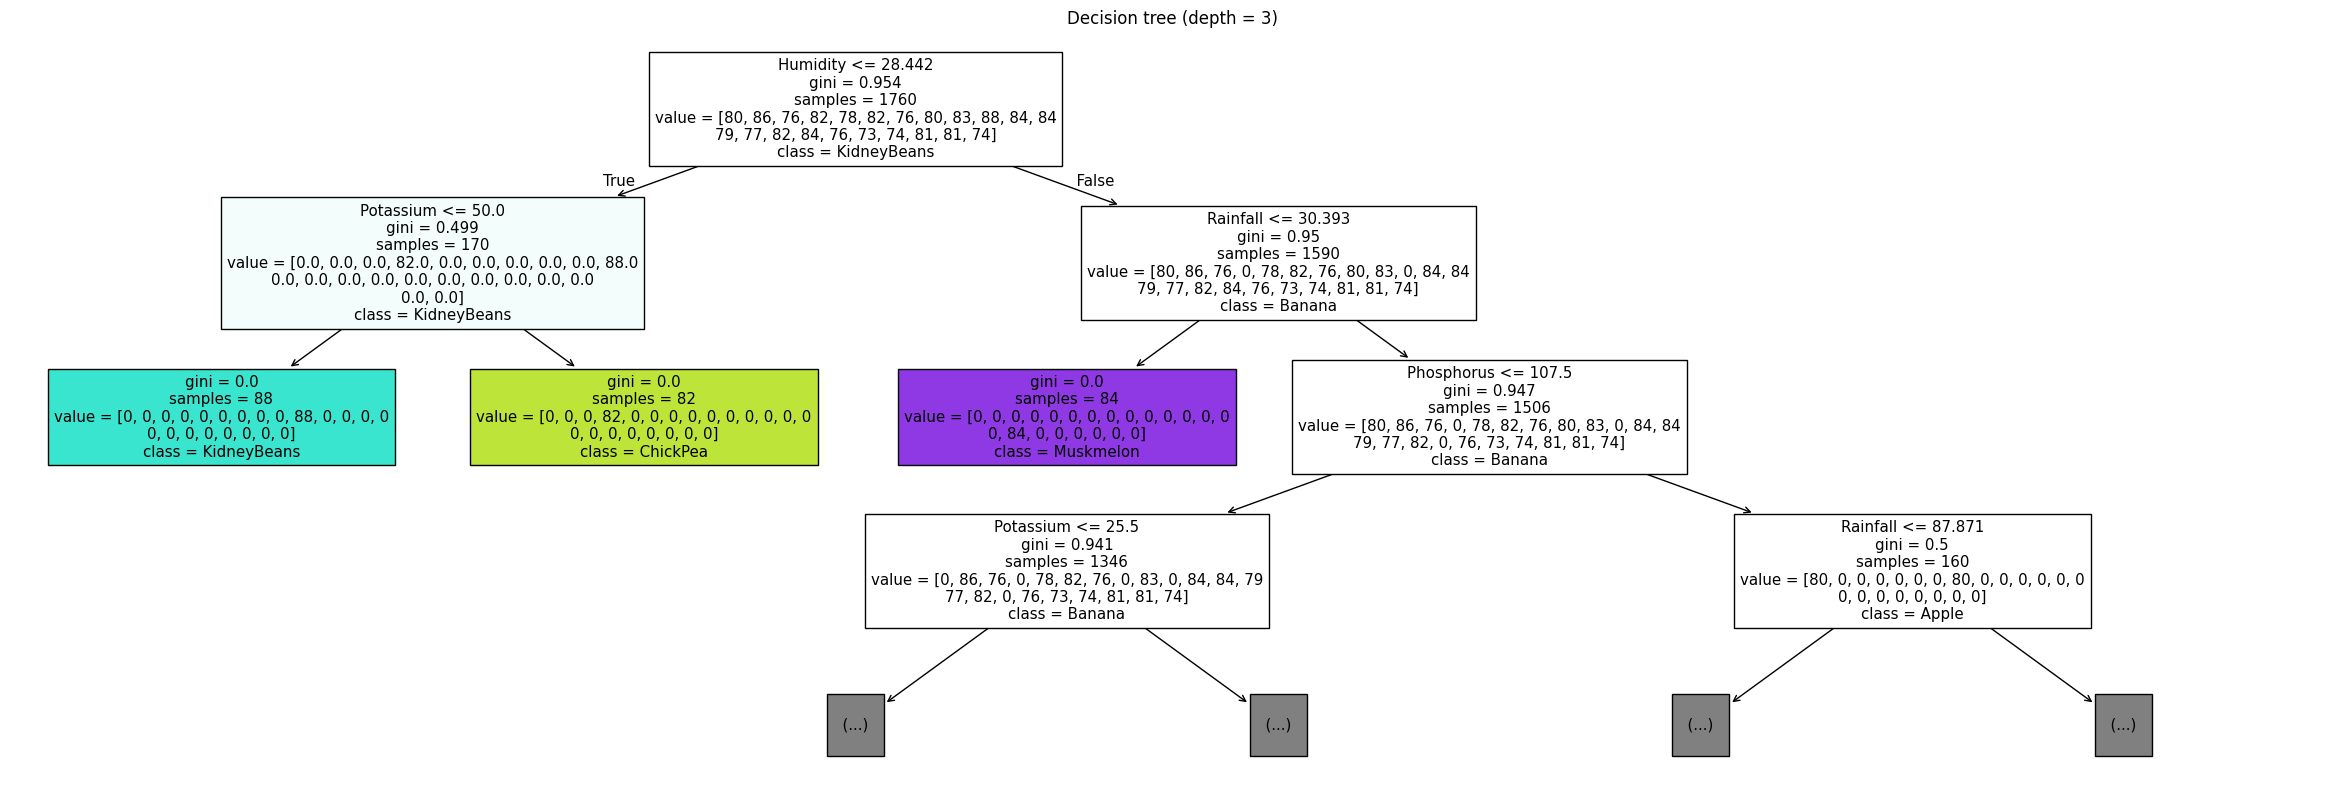

In [104]:
#VISUALIZE TREE
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_visual_depth = 3

plt.figure(figsize = (30, 10))
plot_tree(dt,
          feature_names = df.drop(columns="Crop").columns.tolist(),
          class_names = dt.classes_,
          filled = True,
          max_depth = tree_visual_depth)
plt.title("Decision tree (depth = " + str(tree_visual_depth) + ")")
plt.show()

In [105]:
#BONUS - RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 100, random_state = 50)
rf.fit(train_data['x'], train_data['y'])

y_pred_rf = rf.predict(test_data['x'])

accuracies_rf = []
for i in range(len(y_pred_rf)):
    accuracies_rf.append(y_pred_rf[i] == test_data['y'][i])
accuracy_rf = sum(accuracies_rf) / len(accuracies_rf)
print("Random Forest accuracy:", accuracy_rf)

Random Forest accuracy: 0.9954545454545455
